Explain code with details:

https://chatgpt.com/c/68dd41a7-439c-8328-a711-db59260691aa

In [1]:
# https://www.kaggle.com/crowdflower/twitter-airline-sentiment
!wget -nc https://lazyprogrammer.me/course_files/AirlineTweets.csv

--2025-10-01 14:58:37--  https://lazyprogrammer.me/course_files/AirlineTweets.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 172.67.213.166, 104.21.23.210, 2606:4700:3031::6815:17d2, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|172.67.213.166|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3421431 (3.3M) [text/csv]
Saving to: ‘AirlineTweets.csv’

AirlineTweets.csv   100%[===================>]   3.26M  --.-KB/s    in 0.06s   

2025-10-01 14:58:37 (52.2 MB/s) - ‘AirlineTweets.csv’ saved [3421431/3421431]



wget: download the file

-nc: do not overwirte an existing file

In [2]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

np.random.seed(1)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [5]:
df_ = pd.read_csv('AirlineTweets.csv')

In [6]:
df_.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [8]:
# filters the columns that I want
# copy() make a new independent copy of that subset
df = df_[['airline_sentiment', 'text']].copy()

In [9]:
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


<Axes: >

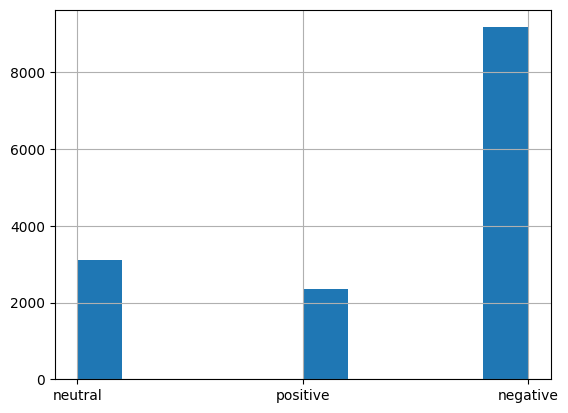

In [10]:
df['airline_sentiment'].hist()

Always use the histogram to check if the class is imbalanced. the above class is imbalanced.

Since the class is imbalanced we should use confusion matrix or AUC.

In [11]:
target_map = {'positive':1, 'negative':0, 'neutral': 2}
df['target']= df['airline_sentiment'].map(target_map)

In [12]:
df.head()

,airline_sentiment,text,target
0,neutral,@VirginAmerica What @dhepburn said.,2
1,positive,@VirginAmerica plus you've added commercials t...,1
2,neutral,@VirginAmerica I didn't today... Must mean I n...,2
3,negative,@VirginAmerica it's really aggressive to blast...,0
4,negative,@VirginAmerica and it's a really big bad thing...,0


In [13]:
df_train, df_test = train_test_split(df)

In [14]:
df_train.head()

,airline_sentiment,text,target
1041,negative,@united Change made in just over 3 hours. For ...,0
1989,negative,@united The engineer that designed the 787 doo...,0
14309,negative,"@AmericanAir 11 out of 11 delayed flights, you...",0
1711,negative,@united ouch not fair,0
11542,negative,@USAirways stuck in cae need reFlight Booking ...,0


In [16]:
vectorizer = TfidfVectorizer(max_features=2000)

If you set max_features=N, it will only keep the top N words (by frequency or importance, depending on the vectorizer).

In [17]:
X_train = vectorizer.fit_transform(df_train['text'])

In [18]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 157851 stored elements and shape (10980, 2000)>

Difference between df_train and X_train:

df_train: A pandas DataFrame (subset of your original df).
Contains the raw training data, including text and labels.

Example structure:

airline_sentiment	text
positive	"I love this airline!"
negative	"The flight was delayed again 😡"

It still has human-readable text.

X_train:A numerical feature matrix (usually a sparse matrix from scikit-learn).
Produced by the TF-IDF vectorizer from the text column.

Each row = one document (tweet).
Each column = one word/feature (up to max_features=2000).

Values = TF-IDF weights (importance of that word in that document).

Example (simplified, only 4 features):

"airline"	"love"	"delayed"	"flight"
0.0	0.8	0.0	0.6
0.2	0.0	0.9	0.5

→ This is what you feed into ML algorithms (Naive Bayes, SVM, Logistic Regression, etc.).

In [20]:
X_test = vectorizer.transform(df_test['text'])

In [22]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52208 stored elements and shape (3660, 2000)>

In [23]:
Y_train= df_train['target']
Y_test= df_test['target']

In [24]:
model= LogisticRegression(max_iter=500)
model.fit(X_train,Y_train)
print("Train accuracy:", model.score(X_train, Y_train))
print("Test accuracy:", model.score(X_test,Y_test))


Train accuracy: 0.8549180327868853
Test accuracy: 0.7991803278688525


In [26]:
Pr_train = model.predict_proba(X_train)
Pr_test= model.predict_proba(X_test)
print("Train AUC:", roc_auc_score(Y_train, Pr_train,multi_class = 'ovo'))
print("Test AUC:", roc_auc_score(Y_test, Pr_test, multi_class= 'ovo'))

Train AUC: 0.9429477299894263
Test AUC: 0.8951758857131157


'ovo' = one-vs-one: compute ROC AUC for each pair of classes, then average.

In [28]:
P_train= model.predict(X_train)
P_test= model.predict(X_test)

Difference vs predict_proba

predict_proba → gives probabilities for each class (e.g. [0.1, 0.7, 0.2]).

predict → picks the most likely class (the one with highest probability).

Example:

proba = [0.1, 0.7, 0.2]  →  predict = 'neutral'

In [34]:
# confusion matrix for train set
cm = confusion_matrix(Y_train,P_train, normalize='true')
cm

array([[0.96486133, 0.00827646, 0.0268622 ],
       [0.19909502, 0.70022624, 0.10067873],
       [0.30107527, 0.05204301, 0.64688172]])

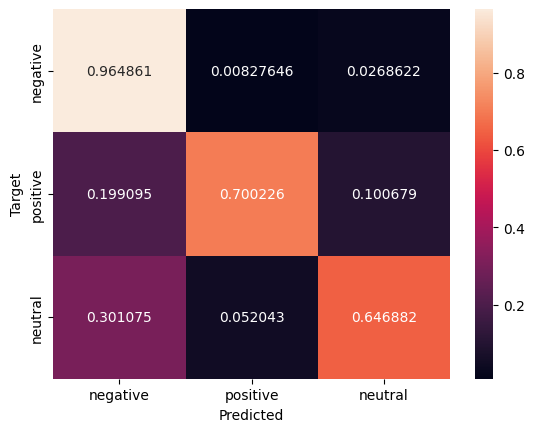

In [35]:
# Scikit-Learn is transitioning to V1 but it's not available on Colab
# The changes modify how confusion matrices are plotted
def plot_cm(cm):
  classes = ['negative', 'positive', 'neutral']
  df_cm = pd.DataFrame(cm, index=classes, columns=classes)
  ax = sn.heatmap(df_cm, annot=True, fmt='g')
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Target")

plot_cm(cm)

In [36]:
# confusion matrix for test set
cm_test = confusion_matrix(Y_test, P_test, normalize='true')
cm_test

array([[0.93103448, 0.01702313, 0.05194238],
       [0.24369748, 0.63865546, 0.11764706],
       [0.41085271, 0.05684755, 0.53229974]])

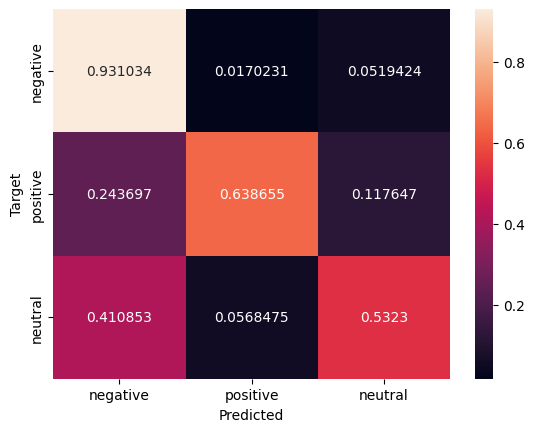

In [37]:
plot_cm(cm_test)

in the below cell we remove neutral lables and make the class binary


In [38]:
binary_target_list = [target_map['positive'], target_map['negative']]
df_binary_train = df_train[df_train['target'].isin(binary_target_list)]
df_binary_test = df_test[df_test['target'].isin(binary_target_list)]

In [39]:
df_binary_train.head()

,airline_sentiment,text,target
1041,negative,@united Change made in just over 3 hours. For ...,0
1989,negative,@united The engineer that designed the 787 doo...,0
14309,negative,"@AmericanAir 11 out of 11 delayed flights, you...",0
1711,negative,@united ouch not fair,0
11542,negative,@USAirways stuck in cae need reFlight Booking ...,0


In [40]:
X_train_binary = vectorizer.fit_transform(df_binary_train['text'])
X_test_binary = vectorizer.transform(df_binary_test['text'])

In [41]:
Y_train_binary = df_binary_train['target']
Y_test_binary = df_binary_test['target']

In [43]:
model_binary = LogisticRegression(max_iter=500)
model_binary.fit(X_train_binary, Y_train_binary)
print("Train accuracy:", model_binary.score(X_train_binary, Y_train_binary))
print("Test accuracy:", model_binary.score(X_test_binary, Y_test_binary))

Train accuracy: 0.9298671288272675
Test accuracy: 0.9144144144144144


by removing neutral labels we improved our model accuracy


In [45]:
Pr_train= model_binary.predict_proba(X_train_binary)[:,1]
Pr_test= model_binary.predict_proba(X_test_binary)[:,1]
# since we have binary classes we added [:,1]
print("Train AUC:", roc_auc_score(Y_train_binary, Pr_train))
print("Test AUC:", roc_auc_score(Y_test_binary, Pr_test))

Train AUC: 0.9788541037708268
Test AUC: 0.953128610676047


In [46]:
model.coef_

array([[ 0.39490132,  0.34423402,  0.4509593 , ...,  0.27948156,
         0.93542272, -0.69655031],
       [-0.19334891, -0.23385151, -0.0551669 , ...,  0.09994324,
        -0.33410699,  0.17506706],
       [-0.20155241, -0.11038251, -0.3957924 , ..., -0.3794248 ,
        -0.60131573,  0.52148325]])

After training (model.fit(...)), the model learns a weight (coefficient) for each input feature.

model.coef_ stores those learned weights.

(array([  1.,   1.,   0.,   0.,   0.,   0.,   1.,   4.,   2.,   1.,   3.,
          9.,  24.,  54., 166., 292., 403., 395., 319., 163.,  87.,  28.,
         17.,  13.,   5.,   4.,   3.,   1.,   1.,   3.]),
 array([-4.38178921, -4.12053134, -3.85927347, -3.5980156 , -3.33675773,
        -3.07549986, -2.81424199, -2.55298412, -2.29172626, -2.03046839,
        -1.76921052, -1.50795265, -1.24669478, -0.98543691, -0.72417904,
        -0.46292117, -0.2016633 ,  0.05959457,  0.32085243,  0.5821103 ,
         0.84336817,  1.10462604,  1.36588391,  1.62714178,  1.88839965,
         2.14965752,  2.41091539,  2.67217326,  2.93343112,  3.19468899,
         3.45594686]),
 <BarContainer object of 30 artists>)

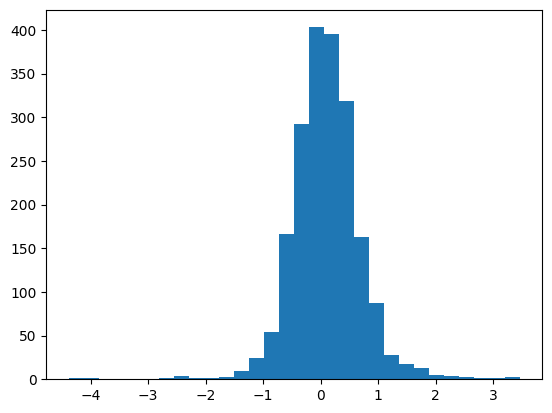

In [47]:
plt.hist(model.coef_[0],bins = 30)

In [48]:
# vectorizer.vocabulary_ = a dictionary of word → column index
word_index_map = vectorizer.vocabulary_
word_index_map

{'united': np.int64(1845),
 'change': np.int64(342),
 'made': np.int64(1093),
 'in': np.int64(943),
 'just': np.int64(994),
 'over': np.int64(1276),
 'hours': np.int64(907),
 'for': np.int64(755),
 'something': np.int64(1623),
 'that': np.int64(1729),
 'should': np.int64(1579),
 'have': np.int64(858),
 'taken': np.int64(1703),
 'online': np.int64(1250),
 'am': np.int64(138),
 'not': np.int64(1217),
 'loved': np.int64(1082),
 'the': np.int64(1731),
 'agent': np.int64(109),
 'though': np.int64(1747),
 'designed': np.int64(528),
 'door': np.int64(578),
 'to': np.int64(1767),
 'half': np.int64(836),
 'into': np.int64(969),
 'plane': np.int64(1336),
 'seat': np.int64(1539),
 'be': np.int64(237),
 'forced': np.int64(756),
 'always': np.int64(137),
 'sit': np.int64(1595),
 'here': np.int64(880),
 'americanair': np.int64(142),
 '11': np.int64(6),
 'out': np.int64(1271),
 'of': np.int64(1231),
 'delayed': np.int64(506),
 'flights': np.int64(738),
 'you': np.int64(1993),
 'suck': np.int64(1675),

In [49]:
# let's look at the weights for each word
# try it with different threshold values!
threshold = 2

print("Most positive words:")
for word, index in word_index_map.items():
    weight = model.coef_[0][index]
    if weight > threshold:
        print(word, weight)

Most positive words:
worse 3.2214250162464424
disappointment 2.1185680739997035
look 2.1252837651611385
cant 2.632504602830406
noon 2.172678189633696
whole 2.3863683915941913
honor 2.995174451692947
such 2.2823517868888032
honeymoon 2.067742206544389
non 3.2451144191197443
dealing 2.8417820587791156
loving 2.3191901518548317
news 3.4559468619289544
deal 2.4337515181739535
hence 2.555867080837402


In [50]:
print("Most negative words:")
for word, index in word_index_map.items():
    weight = model.coef_[0][index]
    if weight < -threshold:
        print(word, weight)

Most negative words:
the -4.3817892070145055
their -3.9660001753140186
lose -2.5480499578956906
isn -2.5046514137086806
gold -2.1248900704609346
vegas -2.59253169504301
american -2.4188860670095655
south -2.35688309236904
worried -2.2090885760930874
